In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

from xgboost import XGBRegressor


project_root = Path.cwd().parent

demand_path = (
    project_root
    / "data"
    / "processed"
    / "vic_demand_2024-07_to_2026-06.parquet"
)

weather_path = (
    project_root
    / "data"
    / "processed"
    / "melbourne_weather_2024-07_to_2026-06.parquet"
)

df = pd.read_parquet(demand_path)

weather = pd.read_parquet(weather_path)

df = df[
    df["SETTLEMENTDATE"] < pd.Timestamp("2026-07-01")
].copy()

df = df.sort_values("SETTLEMENTDATE").reset_index(drop=True)

weather = weather.sort_values("SETTLEMENTDATE").reset_index(drop=True)

In [2]:
weather = weather.rename(
    columns={
        "SETTLEMENTDATE": "WEATHER_TIME"
    }
)

df = pd.merge_asof(
    df.sort_values("SETTLEMENTDATE"),
    weather.sort_values("WEATHER_TIME"),
    left_on="SETTLEMENTDATE",
    right_on="WEATHER_TIME",
    direction="backward",
)

df[
    [
        "SETTLEMENTDATE",
        "WEATHER_TIME",
        "TOTALDEMAND",
        "temperature_2m",
        "apparent_temperature",
    ]
].head(15)

,SETTLEMENTDATE,WEATHER_TIME,TOTALDEMAND,temperature_2m,apparent_temperature
0,2024-07-01 00:05:00,2024-07-01 00:00:00,5404.13,9.3,5.7
1,2024-07-01 00:10:00,2024-07-01 00:00:00,5346.60,9.3,5.7
2,2024-07-01 00:15:00,2024-07-01 00:00:00,5240.84,9.3,5.7
3,2024-07-01 00:20:00,2024-07-01 00:00:00,5239.06,9.3,5.7
4,2024-07-01 00:25:00,2024-07-01 00:00:00,5226.10,9.3,5.7
5,2024-07-01 00:30:00,2024-07-01 00:00:00,5237.71,9.3,5.7
6,2024-07-01 00:35:00,2024-07-01 00:00:00,5198.55,9.3,5.7
7,2024-07-01 00:40:00,2024-07-01 00:00:00,5163.32,9.3,5.7
8,2024-07-01 00:45:00,2024-07-01 00:00:00,5150.10,9.3,5.7
9,2024-07-01 00:50:00,2024-07-01 00:00:00,5158.83,9.3,5.7


In [3]:
future_weather_rows = (
    df["WEATHER_TIME"]
    > df["SETTLEMENTDATE"]
).sum()

weather_age = (
    df["SETTLEMENTDATE"]
    - df["WEATHER_TIME"]
)

print(
    "Rows using future weather:",
    future_weather_rows,
)

print(
    "Maximum weather age:",
    weather_age.max(),
)

print()
print("Missing merged weather values:")
print(
    df[
        [
            "temperature_2m",
            "apparent_temperature",
            "relative_humidity_2m",
            "precipitation",
            "wind_speed_10m",
        ]
    ].isna().sum()
)

Rows using future weather: 0
Maximum weather age: 0 days 00:55:00

Missing merged weather values:
temperature_2m          0
apparent_temperature    0
relative_humidity_2m    0
precipitation           0
wind_speed_10m          0
dtype: int64


In [4]:
FORECAST_HORIZON = 6

df["FORECAST_TIME"] = (
    df["SETTLEMENTDATE"]
    + pd.Timedelta(minutes=30)
)

df["target_30m"] = (
    df["TOTALDEMAND"]
    .shift(-FORECAST_HORIZON)
)

# Current and lagged demand
df["demand_current"] = df["TOTALDEMAND"]
df["demand_lag_5m"] = df["TOTALDEMAND"].shift(1)
df["demand_lag_15m"] = df["TOTALDEMAND"].shift(3)
df["demand_lag_30m"] = df["TOTALDEMAND"].shift(6)
df["demand_lag_1h"] = df["TOTALDEMAND"].shift(12)
df["demand_lag_2h"] = df["TOTALDEMAND"].shift(24)

# Historical comparable times
df["same_time_yesterday"] = (
    df["TOTALDEMAND"]
    .shift(288 - FORECAST_HORIZON)
)

df["same_time_last_week"] = (
    df["TOTALDEMAND"]
    .shift(2016 - FORECAST_HORIZON)
)

# Recent trajectory
df["change_15m"] = (
    df["TOTALDEMAND"]
    - df["TOTALDEMAND"].shift(3)
)

df["change_30m"] = (
    df["TOTALDEMAND"]
    - df["TOTALDEMAND"].shift(6)
)

df["change_1h"] = (
    df["TOTALDEMAND"]
    - df["TOTALDEMAND"].shift(12)
)

# Rolling statistics
df["rolling_mean_30m"] = (
    df["TOTALDEMAND"]
    .rolling(6)
    .mean()
)

df["rolling_mean_1h"] = (
    df["TOTALDEMAND"]
    .rolling(12)
    .mean()
)

df["rolling_std_1h"] = (
    df["TOTALDEMAND"]
    .rolling(12)
    .std()
)

# Calendar information for forecast target
df["target_hour"] = df["FORECAST_TIME"].dt.hour
df["target_minute"] = df["FORECAST_TIME"].dt.minute
df["target_day_of_week"] = df["FORECAST_TIME"].dt.dayofweek
df["target_month"] = df["FORECAST_TIME"].dt.month

df["target_is_weekend"] = (
    df["target_day_of_week"] >= 5
).astype(int)

In [5]:
base_features = [
    "demand_current",
    "demand_lag_5m",
    "demand_lag_15m",
    "demand_lag_30m",
    "demand_lag_1h",
    "demand_lag_2h",
    "same_time_yesterday",
    "same_time_last_week",
    "change_15m",
    "change_30m",
    "change_1h",
    "rolling_mean_30m",
    "rolling_mean_1h",
    "rolling_std_1h",
    "target_hour",
    "target_minute",
    "target_day_of_week",
    "target_month",
    "target_is_weekend",
]

weather_features = [
    "temperature_2m",
    "apparent_temperature",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
]

full_features = (
    base_features
    + weather_features
)

model_df = df.dropna(
    subset=full_features + ["target_30m"]
).copy()

train = model_df[
    model_df["FORECAST_TIME"] < "2026-03-01"
].copy()

validation = model_df[
    (model_df["FORECAST_TIME"] >= "2026-03-01")
    & (model_df["FORECAST_TIME"] < "2026-05-01")
].copy()

test = model_df[
    (model_df["FORECAST_TIME"] >= "2026-05-01")
    & (model_df["FORECAST_TIME"] < "2026-07-01")
].copy()

print(f"Train:      {len(train):,}")
print(f"Validation: {len(validation):,}")
print(f"Test:       {len(test):,}")

Train:      173,087
Validation: 17,568
Test:       17,568


In [6]:
def make_xgb_model() -> XGBRegressor:
    return XGBRegressor(
        objective="reg:squarederror",
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
    )

In [7]:
base_model = make_xgb_model()

base_model.fit(
    train[base_features],
    train["target_30m"],
)

base_predictions = base_model.predict(
    validation[base_features]
)


weather_model = make_xgb_model()

weather_model.fit(
    train[full_features],
    train["target_30m"],
)

weather_predictions = weather_model.predict(
    validation[full_features]
)


base_mae = mean_absolute_error(
    validation["target_30m"],
    base_predictions,
)

base_rmse = np.sqrt(
    mean_squared_error(
        validation["target_30m"],
        base_predictions,
    )
)

weather_mae = mean_absolute_error(
    validation["target_30m"],
    weather_predictions,
)

weather_rmse = np.sqrt(
    mean_squared_error(
        validation["target_30m"],
        weather_predictions,
    )
)

weather_improvement = (
    (base_mae - weather_mae)
    / base_mae
    * 100
)

print(
    f"Base XGBoost MAE:     "
    f"{base_mae:.2f} MW"
)

print(
    f"Weather XGBoost MAE:  "
    f"{weather_mae:.2f} MW"
)

print()

print(
    f"Base XGBoost RMSE:    "
    f"{base_rmse:.2f} MW"
)

print(
    f"Weather XGBoost RMSE: "
    f"{weather_rmse:.2f} MW"
)

print()

print(
    f"MAE improvement from weather: "
    f"{weather_improvement:.2f}%"
)

Base XGBoost MAE:     77.25 MW
Weather XGBoost MAE:  75.90 MW

Base XGBoost RMSE:    107.46 MW
Weather XGBoost RMSE: 104.84 MW

MAE improvement from weather: 1.74%


In [8]:
weather_comparison = pd.DataFrame(
    {
        "Model": [
            "XGBoost",
            "XGBoost + weather",
        ],
        "MAE_MW": [
            base_mae,
            weather_mae,
        ],
        "RMSE_MW": [
            base_rmse,
            weather_rmse,
        ],
    }
)

weather_comparison

,Model,MAE_MW,RMSE_MW
0,XGBoost,77.245516,107.458023
1,XGBoost + weather,75.903300,104.836096


In [9]:
feature_importance = (
    pd.DataFrame(
        {
            "feature": full_features,
            "importance": (
                weather_model.feature_importances_
            ),
        }
    )
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

feature_importance.head(15)

,feature,importance
0,demand_current,0.621821
1,demand_lag_5m,0.345787
2,change_30m,0.007870
3,change_1h,0.007769
4,target_hour,0.002860
5,rolling_mean_30m,0.002527
6,change_15m,0.001851
7,apparent_temperature,0.001030
8,rolling_std_1h,0.000987
9,target_is_weekend,0.000832


### Weather features

Historical Melbourne weather was merged with the five-minute AEMO demand
series using a backward time join.

This ensures that each electricity-demand observation receives only the
most recently available weather observation. Validation confirmed that no
rows use future weather information and that the maximum age of an assigned
weather observation is 55 minutes.

Adding weather variables improved validation performance:

- Base XGBoost MAE: 77.25 MW
- XGBoost + weather MAE: 75.90 MW
- Base XGBoost RMSE: 107.46 MW
- XGBoost + weather RMSE: 104.84 MW

This represents a 1.74% reduction in MAE.

The gain is materially smaller than the improvements produced by recent
demand and calendar features. This is reasonable for a 30-minute forecasting
horizon because much of the immediate effect of weather is already reflected
in current electricity demand.

Before weather is retained in the final model, its contribution is evaluated
across several historical validation periods rather than relying on a single
two-month validation window.

In [10]:
backtest_folds = [
    {
        "name": "Sep–Oct 2025",
        "train_end": "2025-09-01",
        "validation_start": "2025-09-01",
        "validation_end": "2025-11-01",
    },
    {
        "name": "Nov–Dec 2025",
        "train_end": "2025-11-01",
        "validation_start": "2025-11-01",
        "validation_end": "2026-01-01",
    },
    {
        "name": "Jan–Feb 2026",
        "train_end": "2026-01-01",
        "validation_start": "2026-01-01",
        "validation_end": "2026-03-01",
    },
    {
        "name": "Mar–Apr 2026",
        "train_end": "2026-03-01",
        "validation_start": "2026-03-01",
        "validation_end": "2026-05-01",
    },
]

backtest_folds

[{'name': 'Sep–Oct 2025',
  'train_end': '2025-09-01',
  'validation_start': '2025-09-01',
  'validation_end': '2025-11-01'},
 {'name': 'Nov–Dec 2025',
  'train_end': '2025-11-01',
  'validation_start': '2025-11-01',
  'validation_end': '2026-01-01'},
 {'name': 'Jan–Feb 2026',
  'train_end': '2026-01-01',
  'validation_start': '2026-01-01',
  'validation_end': '2026-03-01'},
 {'name': 'Mar–Apr 2026',
  'train_end': '2026-03-01',
  'validation_start': '2026-03-01',
  'validation_end': '2026-05-01'}]

In [11]:
backtest_results = []

for fold in backtest_folds:
    fold_train = model_df[
        model_df["FORECAST_TIME"] < fold["train_end"]
    ].copy()

    fold_validation = model_df[
        (model_df["FORECAST_TIME"] >= fold["validation_start"])
        & (model_df["FORECAST_TIME"] < fold["validation_end"])
    ].copy()

    base_fold_model = make_xgb_model()
    base_fold_model.fit(
        fold_train[base_features],
        fold_train["target_30m"],
    )

    base_fold_predictions = base_fold_model.predict(
        fold_validation[base_features]
    )

    weather_fold_model = make_xgb_model()
    weather_fold_model.fit(
        fold_train[full_features],
        fold_train["target_30m"],
    )

    weather_fold_predictions = weather_fold_model.predict(
        fold_validation[full_features]
    )

    base_fold_mae = mean_absolute_error(
        fold_validation["target_30m"],
        base_fold_predictions,
    )

    weather_fold_mae = mean_absolute_error(
        fold_validation["target_30m"],
        weather_fold_predictions,
    )

    improvement = (
        (base_fold_mae - weather_fold_mae)
        / base_fold_mae
        * 100
    )

    backtest_results.append(
        {
            "Validation period": fold["name"],
            "Training rows": len(fold_train),
            "Base MAE": base_fold_mae,
            "Weather MAE": weather_fold_mae,
            "Weather improvement %": improvement,
        }
    )

backtest_results = pd.DataFrame(backtest_results)

backtest_results

,Validation period,Training rows,Base MAE,Weather MAE,Weather improvement %
0,Sep–Oct 2025,120959,92.922596,91.963379,1.032275
1,Nov–Dec 2025,138527,93.229319,92.737940,0.527065
2,Jan–Feb 2026,156095,89.054707,83.120959,6.663037
3,Mar–Apr 2026,173087,77.245516,75.903300,1.737598


In [12]:
print(
    f"Mean base MAE: "
    f"{backtest_results['Base MAE'].mean():.2f} MW"
)

print(
    f"Mean weather MAE: "
    f"{backtest_results['Weather MAE'].mean():.2f} MW"
)

print(
    f"Mean weather improvement: "
    f"{backtest_results['Weather improvement %'].mean():.2f}%"
)

print(
    f"Weather improved "
    f"{(backtest_results['Weather improvement %'] > 0).sum()} "
    f"of {len(backtest_results)} folds"
)

Mean base MAE: 88.11 MW
Mean weather MAE: 85.93 MW
Mean weather improvement: 2.49%
Weather improved 4 of 4 folds


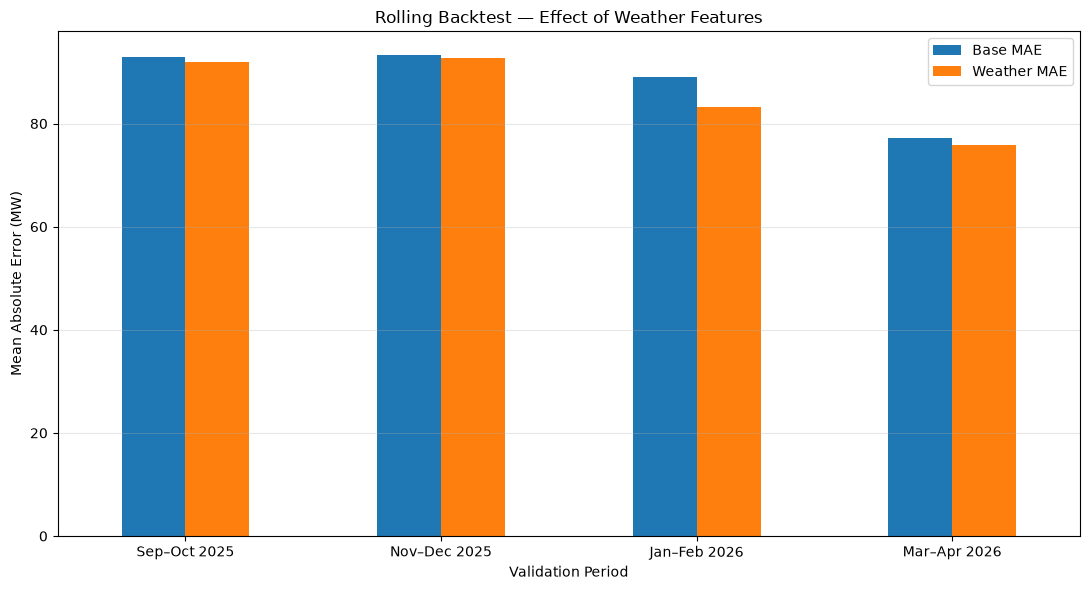

In [13]:
plot_data = backtest_results.set_index(
    "Validation period"
)[
    ["Base MAE", "Weather MAE"]
]

plot_data.plot(
    kind="bar",
    figsize=(11, 6),
)

plt.title(
    "Rolling Backtest — Effect of Weather Features"
)
plt.xlabel("Validation Period")
plt.ylabel("Mean Absolute Error (MW)")
plt.xticks(rotation=0)
plt.grid(
    axis="y",
    alpha=0.3,
)
plt.tight_layout()
plt.show()

### Rolling backtest

Weather features were evaluated across four expanding-window historical
validation periods rather than relying only on the March–April 2026
validation period.

Weather improved forecast accuracy in all four folds:

- Sep–Oct 2025: 1.03% lower MAE
- Nov–Dec 2025: 0.53% lower MAE
- Jan–Feb 2026: 6.66% lower MAE
- Mar–Apr 2026: 1.74% lower MAE

Across the four validation periods, mean MAE decreased from 88.11 MW to
85.93 MW, an average improvement of approximately 2.49%.

The largest improvement occurred during January–February, consistent with
weather being particularly informative during periods of stronger
temperature-driven electricity demand.

Weather is therefore retained in the final model specification.

The final model specification is frozen before evaluating the May–June 2026
holdout test period.